# 3. Simulating many cooling rounds

**This is the main notebook.**

Every thermal cycle re-traps the interface charge from scratch. So each cooldown
of the same physical device hands you a *fresh draw* from the disorder
distribution — new inter-dot distance, new tunnel coupling, new detuning. Nothing
in the model distinguishes "the same device, recooled" from "a different device
off the same wafer": both are `model.sample()`.

Here we draw thousands of them in a second, from either generative model, and ask
what that does to a device.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))  # so `import chargetwin` works from notebooks/

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import chargetwin as ct

## Choose your generator

Two routes, both giving a model with the same `.sample()` API:

1. **Load a precomputed fit** — fastest, no raw data needed.
2. **Refit from the raw ensemble** — if you changed the parameter set, the
   dataset, or the number of retained modes.

In [2]:
PARAMS = ct.PAPER_PARAMETERS
DATASET = "rho5e10"
N_ROUNDS = 2000
SEED = 42

MODELS = ct.data.DATA_ROOT / "models"

# --- route 1: precomputed -----------------------------------------------
gauss = ct.DisorderModel.load(MODELS / f"{DATASET}_gaussian.npz")
pca = ct.DisorderModel.load(MODELS / f"{DATASET}_pca3.npz")

# --- route 2: refit from raw (uncomment) ---------------------------------
# raw_fit = ct.load_dataset(DATASET, PARAMS)
# gauss = ct.GaussianModel.fit(raw_fit)
# pca = ct.PCAModel.fit(raw_fit, n_components=3)

print("parameters:", gauss.parameters)

parameters: ['d', 'log2tc', 'Lxavg', 'dLx', 'Favg', 'dF', 'eps']


## Draw the cooldowns

One row per thermal cycle. `add_tunnel_coupling` un-logs `log2tc` so we can put a
spec on `t_c` in µeV.

In [3]:
def cooling_rounds(model, n, seed):
    df = ct.add_tunnel_coupling(model.sample(n, seed=seed))
    df.insert(0, "round", np.arange(n))
    return df


rounds_cov = cooling_rounds(gauss, N_ROUNDS, SEED)
rounds_pca = cooling_rounds(pca, N_ROUNDS, SEED)

rounds_cov.head()

,round,d,log2tc,Lxavg,dLx,Favg,dF,eps,tc
0,0,89.343446,1.295479,20.568437,0.996900,5.302427,-0.028460,-3.778917,9.872996
1,1,96.285014,1.276865,20.083719,-0.436264,5.276650,-0.007531,-0.044918,9.458768
2,2,87.578292,1.808620,21.466307,0.661372,5.252736,-0.016470,-3.165549,32.180320
3,3,100.350585,0.968466,20.387841,-0.620544,5.259082,0.013536,4.624263,4.649821
4,4,88.104094,1.583572,21.206316,1.102477,5.275914,-0.030557,1.725072,19.166461


## What a device looks like across cooldowns

The tunnel coupling is the parameter that hurts: it swings across a wide range
from one cooldown to the next, and it is the one you most need inside a target
window.

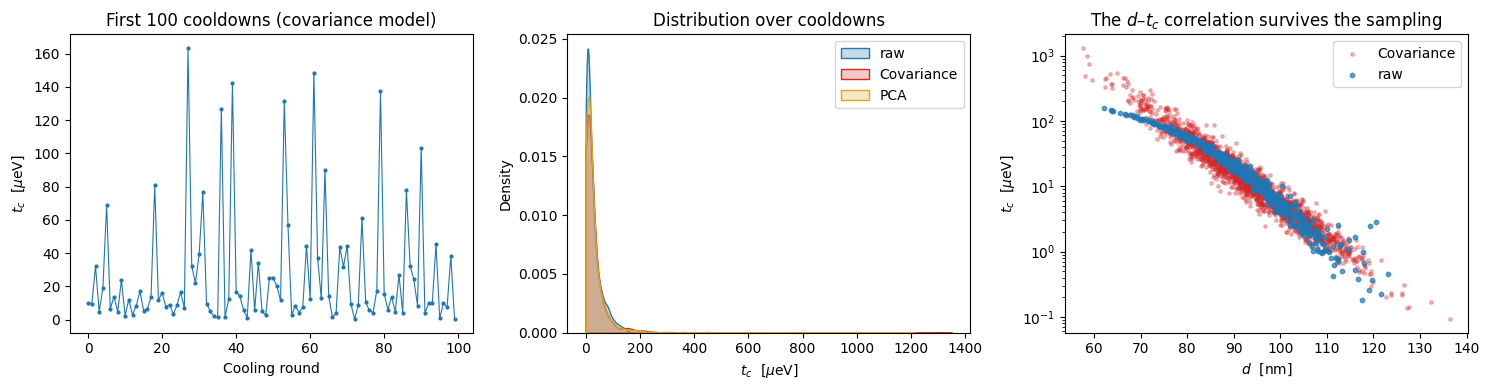

In [4]:
raw = ct.add_tunnel_coupling(ct.load_dataset(DATASET, PARAMS))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(rounds_cov["round"][:100], rounds_cov["tc"][:100], ".-", lw=0.8, ms=4)
axes[0].set_xlabel("Cooling round")
axes[0].set_ylabel(r"$t_c$  [$\mu$eV]")
axes[0].set_title("First 100 cooldowns (covariance model)")

for label, df, c in [("raw", raw, "tab:blue"), ("Covariance", rounds_cov, "tab:red"), ("PCA", rounds_pca, "goldenrod")]:
    sns.kdeplot(df["tc"], ax=axes[1], label=label, color=c, fill=True, alpha=0.25, clip=(0, None))
axes[1].set_xlabel(r"$t_c$  [$\mu$eV]")
axes[1].legend()
axes[1].set_title("Distribution over cooldowns")

axes[2].scatter(rounds_cov["d"], rounds_cov["tc"], s=6, alpha=0.3, c="tab:red", label="Covariance")
axes[2].scatter(raw["d"], raw["tc"], s=10, alpha=0.7, c="tab:blue", label="raw")
axes[2].set_xlabel(r"$d$  [nm]")
axes[2].set_ylabel(r"$t_c$  [$\mu$eV]")
axes[2].set_yscale("log")
axes[2].legend()
axes[2].set_title("The $d$–$t_c$ correlation survives the sampling")

fig.tight_layout()

## Yield: what fraction of cooldowns land in spec?

Define an operating window on the parameters you care about, then count. This is
the payoff — the model turns "how bad is charge disorder?" into a number you can
compute for any spec, without running COMSOL again.

The window below is the paper's tunability criterion (Sec. III A), expressed on
the parameters we carry.

In [5]:
SPEC = {
    "tc": (5.0, 125.0),      # tunnel coupling, ueV  (gap 2*t_c in 10-250 ueV)
    "eps": (-5.0, 5.0),      # residual detuning, meV
    "d": (75.0, 110.0),      # inter-dot distance, nm
}


def in_spec(df, spec=SPEC):
    ok = pd.Series(True, index=df.index)
    for p, (lo, hi) in spec.items():
        ok &= df[p].between(lo, hi)
    return ok


yields = pd.DataFrame(
    [
        {"source": name, "yield": in_spec(df).mean()}
        for name, df in [("raw (COMSOL)", raw), ("Covariance (A)", rounds_cov), ("PCA (B)", rounds_pca)]
    ]
).set_index("source")

yields.style.format("{:.1%}")

,yield
source,
raw (COMSOL),55.8%
Covariance (A),56.8%
PCA (B),62.5%


### Yield vs. how tight the spec is

Sweep one bound and watch the yield fall off. With 2000 synthetic cooldowns the
curve is smooth; with the 500 raw realizations it is visibly noisy — that is the
practical reason to generate rather than resample.

Text(0.5, 1.0, 'Yield vs. spec width')

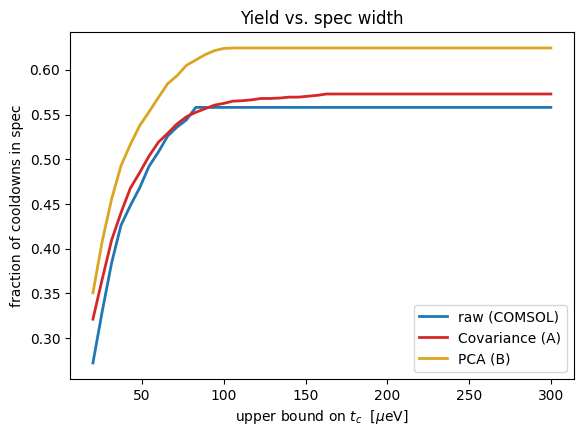

In [6]:
tc_max = np.linspace(20, 300, 50)
curves = {}
for name, df in [("raw (COMSOL)", raw), ("Covariance (A)", rounds_cov), ("PCA (B)", rounds_pca)]:
    curves[name] = [in_spec(df, {**SPEC, "tc": (5.0, hi)}).mean() for hi in tc_max]

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for (name, y), c in zip(curves.items(), ["tab:blue", "tab:red", "goldenrod"]):
    ax.plot(tc_max, y, label=name, color=c, lw=2)
ax.set_xlabel(r"upper bound on $t_c$  [$\mu$eV]")
ax.set_ylabel("fraction of cooldowns in spec")
ax.legend()
ax.set_title("Yield vs. spec width")

### The same question, across charge densities

This is the headline result the generator makes cheap: how much does the
interface charge density cost you in yield?

In [7]:
rows = []
for ds in ("rho5e9", "rho5e10"):
    m = ct.GaussianModel.fit(ct.load_dataset(ds, PARAMS))
    s = ct.add_tunnel_coupling(m.sample(20_000, seed=SEED))
    rows.append({"dataset": ds, "density": ct.DATASETS[ds].density, "yield": in_spec(s).mean()})
pd.DataFrame(rows).set_index("dataset").style.format({"yield": "{:.1%}"})

,density,yield
dataset,,
rho5e9,5e9 cm^-2,95.6%
rho5e10,5e10 cm^-2,56.3%


## Many devices × many cooldowns

Because a cooldown and a new device are the same draw, an experiment with
`n_devices` devices each cooled `n_rounds` times is just a reshape. The spread
across the bars is pure sampling noise — the model has no per-device memory, and
that is a deliberate modelling choice, not an oversight (see the README).

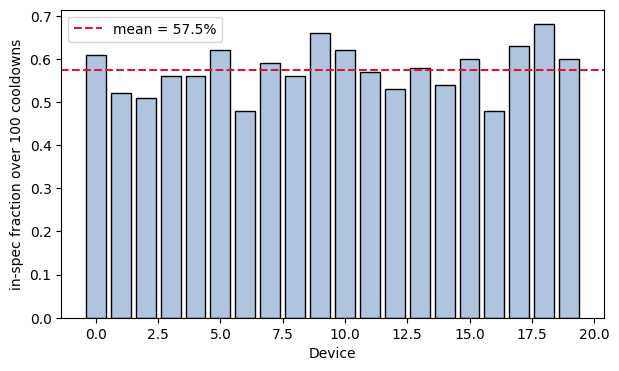

In [8]:
N_DEVICES, N_PER_DEVICE = 20, 100

batch = ct.add_tunnel_coupling(gauss.sample(N_DEVICES * N_PER_DEVICE, seed=7))
batch["device"] = np.repeat(np.arange(N_DEVICES), N_PER_DEVICE)
batch["round"] = np.tile(np.arange(N_PER_DEVICE), N_DEVICES)

per_device_yield = batch.groupby("device").apply(lambda g: in_spec(g).mean(), include_groups=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(per_device_yield.index, per_device_yield.values, color="lightsteelblue", edgecolor="k")
ax.axhline(per_device_yield.mean(), ls="--", c="crimson", label=f"mean = {per_device_yield.mean():.1%}")
ax.set_xlabel("Device")
ax.set_ylabel(f"in-spec fraction over {N_PER_DEVICE} cooldowns")
ax.legend()

## Export

Hand the realizations to whatever comes next — a Schrödinger solver, a tuning
algorithm, an ML training loop.

In [9]:
out = ct.data.DATA_ROOT / "generated"
out.mkdir(exist_ok=True)
rounds_cov.to_csv(out / f"{DATASET}_cooldowns_covariance.csv", index=False)
rounds_pca.to_csv(out / f"{DATASET}_cooldowns_pca3.csv", index=False)
print(f"wrote {N_ROUNDS} cooldowns x 2 models to {out}")

wrote 2000 cooldowns x 2 models to /Users/krzywdaja/openspin-repos/ChargeTwin/data/generated
